In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_excel("/home/vivek/Desktop/BlinkIT Grocery Data.xlsx")
print(df)
df.head(5)

     Item Fat Content Item Identifier              Item Type  \
0             Regular           FDX32  Fruits and Vegetables   
1             Low Fat           NCB42     Health and Hygiene   
2             Regular           FDR28           Frozen Foods   
3             Regular           FDL50                 Canned   
4             Low Fat           DRI25            Soft Drinks   
...               ...             ...                    ...   
8518          low fat           NCT53     Health and Hygiene   
8519          low fat           FDN09            Snack Foods   
8520          low fat           DRE13            Soft Drinks   
8521              reg           FDT50                  Dairy   
8522              reg           FDM58            Snack Foods   

      Outlet Establishment Year Outlet Identifier Outlet Location Type  \
0                          2012            OUT049               Tier 1   
1                          2022            OUT018               Tier 3   
2        

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   str    
 1   Item Identifier            8523 non-null   str    
 2   Item Type                  8523 non-null   str    
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   str    
 5   Outlet Location Type       8523 non-null   str    
 6   Outlet Size                8523 non-null   str    
 7   Outlet Type                8523 non-null   str    
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                7060 non-null   float64
 10  Sales                      8523 non-null   float64
 11  Rating                     8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB


In [4]:
df.isnull().sum()

Item Fat Content                0
Item Identifier                 0
Item Type                       0
Outlet Establishment Year       0
Outlet Identifier               0
Outlet Location Type            0
Outlet Size                     0
Outlet Type                     0
Item Visibility                 0
Item Weight                  1463
Sales                           0
Rating                          0
dtype: int64

In [5]:
df["Item Weight"]

0       15.10
1       11.80
2       13.85
3       12.15
4       19.60
        ...  
8518      NaN
8519      NaN
8520      NaN
8521      NaN
8522      NaN
Name: Item Weight, Length: 8523, dtype: float64

In [6]:
df["Item Weight"]=df["Item Weight"].fillna(df["Item Weight"]).ffill()
print(df["Item Weight"])

0       15.10
1       11.80
2       13.85
3       12.15
4       19.60
        ...  
8518    20.60
8519    20.60
8520    20.60
8521    20.60
8522    20.60
Name: Item Weight, Length: 8523, dtype: float64


In [7]:
df.isnull().sum()

Item Fat Content             0
Item Identifier              0
Item Type                    0
Outlet Establishment Year    0
Outlet Identifier            0
Outlet Location Type         0
Outlet Size                  0
Outlet Type                  0
Item Visibility              0
Item Weight                  0
Sales                        0
Rating                       0
dtype: int64

In [8]:
df.describe()

,Outlet Establishment Year,Item Visibility,Item Weight,Sales,Rating
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,2016.450546,0.066132,13.144058,140.992783,3.965857
std,3.189396,0.051598,4.725439,62.275067,0.605651
min,2011.000000,0.000000,4.555000,31.290000,1.000000
25%,2014.000000,0.026989,9.000000,93.826500,4.000000
50%,2016.000000,0.053931,12.850000,143.012800,4.000000
75%,2018.000000,0.094585,17.250000,185.643700,4.200000
max,2022.000000,0.328391,21.350000,266.888400,5.000000


1. What is the total sales generated by Blinkit?

In [9]:
totalSales=df["Sales"].sum()
print(totalSales)

1201681.4928000001


2. Which Item Type Generate highest sales ? top 10 

In [10]:
total_sales=df.groupby("Item Type")["Sales"].sum().sort_values(ascending=False).head(10)
print(total_sales)

Item Type
Fruits and Vegetables    178124.0810
Snack Foods              175433.9224
Household                135976.5254
Frozen Foods             118558.8814
Dairy                    101276.4616
Canned                    90706.7290
Baking Goods              81894.7364
Health and Hygiene        68025.8388
Meat                      59449.8638
Soft Drinks               58514.1670
Name: Sales, dtype: float64


/tmp/ipykernel_3044/3617615788.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=total_sales,palette="rocket_r")


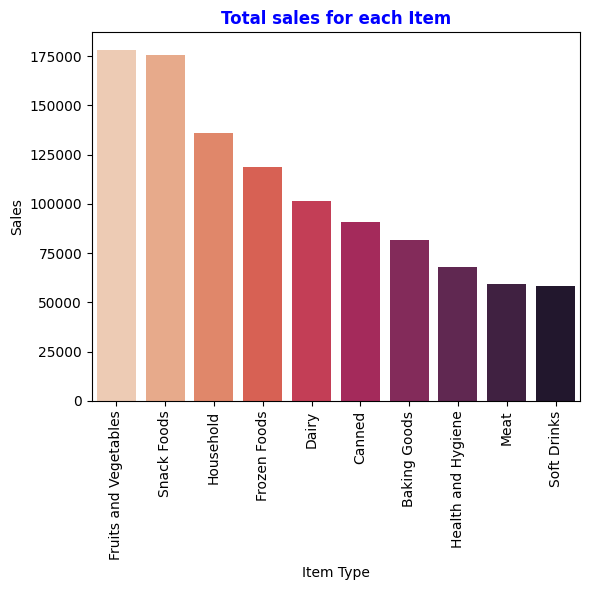

In [11]:
plt.figure(figsize=(6,6))
sns.barplot(data=total_sales,palette="rocket_r")
plt.title("Total sales for each Item",fontweight="bold",color="Blue")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

3. Which outlet type has the highest total sales ?

In [12]:
df["Outlet Type"]

0       Supermarket Type1
1       Supermarket Type2
2       Supermarket Type1
3       Supermarket Type1
4       Supermarket Type1
              ...        
8518    Supermarket Type3
8519    Supermarket Type3
8520    Supermarket Type3
8521    Supermarket Type3
8522    Supermarket Type3
Name: Outlet Type, Length: 8523, dtype: str

In [13]:
outlet_sales=df.groupby("Outlet Type")["Sales"].sum().sort_values(ascending=False)
print(outlet_sales)

Outlet Type
Supermarket Type1    787549.8928
Grocery Store        151939.1490
Supermarket Type2    131477.7764
Supermarket Type3    130714.6746
Name: Sales, dtype: float64


/tmp/ipykernel_3044/3270273498.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=outlet_sales,palette="muted")


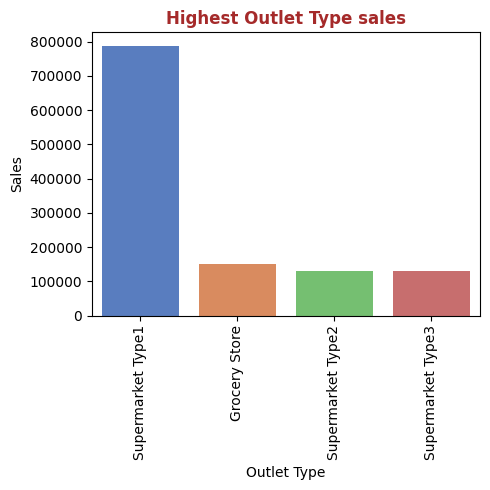

In [14]:
plt.figure(figsize=(5,5))
sns.barplot(data=outlet_sales,palette="muted")
plt.title("Highest Outlet Type sales",fontweight="bold",color="Brown")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

4. What is the sales distribution by outlet location type?

In [15]:
sales_distribution=df.groupby("Outlet Location Type")["Sales"].sum().sort_values(ascending=False)
print(sales_distribution)

Outlet Location Type
Tier 3    472133.0332
Tier 2    393150.6476
Tier 1    336397.8120
Name: Sales, dtype: float64


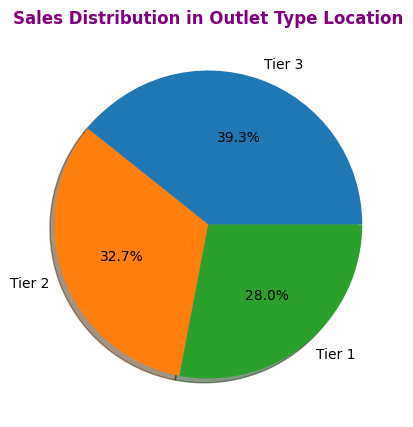

In [16]:
plt.figure(figsize=(5,5))
plt.pie(x=sales_distribution.values,labels=sales_distribution.index,autopct="%1.1f%%",shadow=True)
plt.title("Sales Distribution in Outlet Type Location",fontweight="bold",color="Purple")
plt.show()

5. Which outlet size contribues the most to sales ?

In [17]:
outlet_size=df["Outlet Size"].value_counts()
print(outlet_size)

Outlet Size
Medium    3631
Small     3139
High      1753
Name: count, dtype: int64


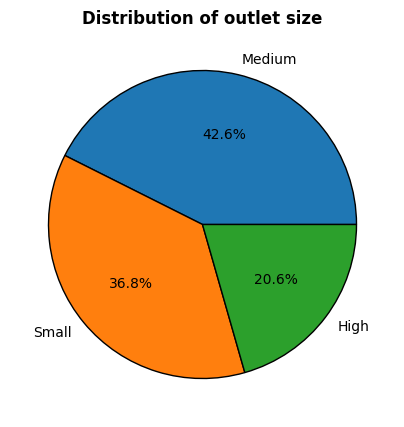

In [18]:
plt.figure(figsize=(5,5))
plt.pie(x=outlet_size.values,labels=outlet_size.index,autopct="%1.1f%%",wedgeprops={'edgecolor':'black'})
plt.title("Distribution of outlet size",fontweight="bold")
plt.show()

6. How has blinkit expanded over the years?

In [19]:
count=df["Outlet Establishment Year"].value_counts()
print(count)

Outlet Establishment Year
2018    1463
2014     932
2012     930
2016     930
2017     930
2015     929
2022     928
2020     926
2011     555
Name: count, dtype: int64


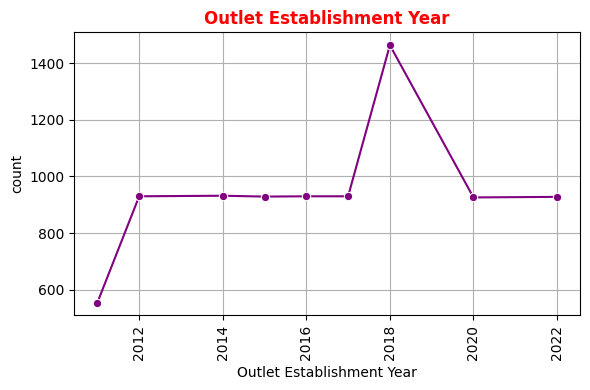

In [20]:
plt.figure(figsize=(6,4))
sns.lineplot(data=count,color="purple",marker="o")
plt.grid(True)
plt.title("Outlet Establishment Year",fontweight="bold",color="red")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

7. Which Item Fat content generates the highest revenue?

In [25]:
df["Item Fat Content"]=df["Item Fat Content"].replace({
    "LF":"Low Fat",
    "low fat":"Low Fat",
    "reg":"Regular"
})
print(df["Item Fat Content"].value_counts())

Item Fat Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64


/tmp/ipykernel_3044/3531074789.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fat_sales.index,y=fat_sales.values,palette="dark")


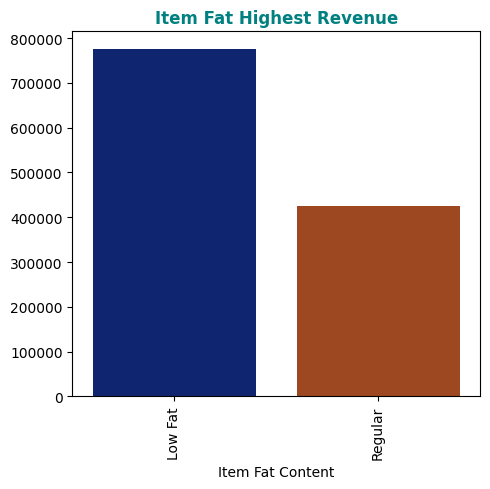

In [27]:
fat_sales=df.groupby("Item Fat Content")["Sales"].sum()
plt.figure(figsize=(5,5))
sns.barplot(x=fat_sales.index,y=fat_sales.values,palette="dark")
plt.title("Item Fat Highest Revenue",fontweight="bold",color="Teal")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

8. Is there any relationship between them Visibility and Sales?

In [ ]:
df[["Item Visibility","Sales"]]

,Item Visibility,Sales
0,0.100014,145.4786
1,0.008596,115.3492
2,0.025896,165.0210
3,0.042278,126.5046
4,0.033970,55.1614
...,...,...
8518,0.000000,164.5526
8519,0.034706,241.6828
8520,0.027571,86.6198
8521,0.107715,97.8752


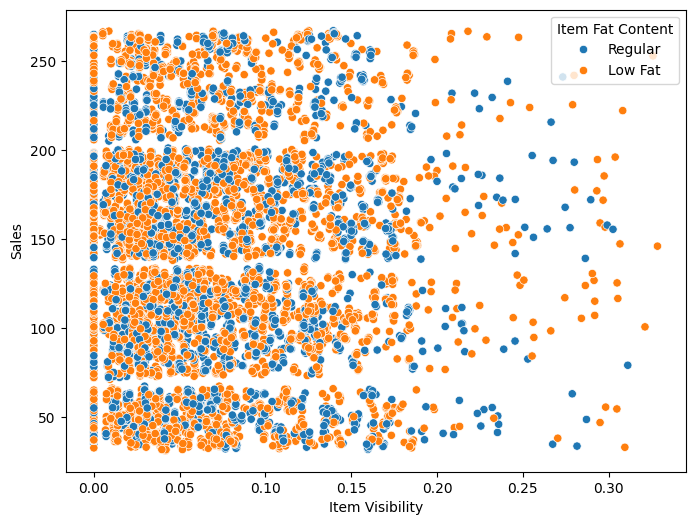

In [32]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="Item Visibility",y="Sales",data=df,hue="Item Fat Content")
plt.show()

9. Which product have the highest average customer rating?

In [ ]:
highest_avgrating=df.groupby("Item Type")["Rating"].mean().sort_values(ascending=False)
print(highest_avgrating)

Item Type
Meat                     4.023059
Household                3.998681
Canned                   3.994299
Health and Hygiene       3.986154
Baking Goods             3.983025
Frozen Foods             3.971145
Dairy                    3.965836
Seafood                  3.959375
Fruits and Vegetables    3.956169
Others                   3.954438
Snack Foods              3.948917
Breakfast                3.932727
Soft Drinks              3.920674
Starchy Foods            3.920270
Hard Drinks              3.907477
Breads                   3.881275
Name: Rating, dtype: float64


/tmp/ipykernel_5378/109455274.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=highest_avgrating.values,y=highest_avgrating.index,palette="Set1")


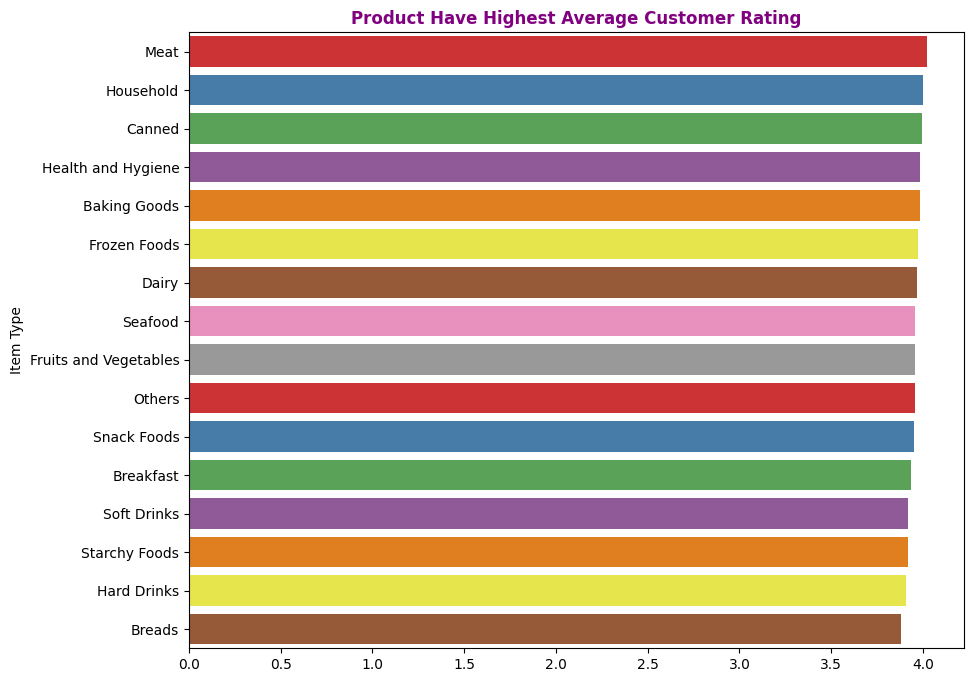

In [ ]:
plt.figure(figsize=(10,8))
sns.barplot(x=highest_avgrating.values,y=highest_avgrating.index,palette="Set1")
plt.title("Product Have Highest Average Customer Rating",fontweight="bold",color="Purple")
plt.show()